# Publication figures for the rotated surface code

**Methodology — which tool for which figure:**

| figure | best tool | why |
|---|---|---|
| syndrome-extraction *circuit*, stabilizer/detector *slices*, match graph | **Stim `circuit.diagram(...)`** | SVG (vector), *correct by construction*, the standard in the literature (Gidney/Google) |
| lattice, **logical operators**, **error → syndrome** | **custom matplotlib** | full control of colours, chains, highlighting; nothing off-the-shelf draws these well |
| **3D decoding graph** with fired detectors | **custom matplotlib 3D** from `get_detector_coordinates()` + DEM edges + a sampled shot | lets you pick exactly which detectors light up |

**Export tips for a thesis/paper:** save **SVG or PDF** (vector) for LaTeX — never a low-dpi PNG; keep text as
text (`svg.fonttype='none'`) so it stays selectable/editable; use one colour-blind-safe palette everywhere;
match the font to the document. Raster only at $\ge300$ dpi. (Alternatives: `quantikz`/`tikz` for hand-tuned
circuits in LaTeX; `qiskit` circuit drawer; `pymatching.Matching.draw` for a quick graph — but Stim's diagrams
are better for QEC.)

All figures below are written to `plots/figures/` as both **SVG** and **PNG (300 dpi)**.

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Wedge, Circle, Patch
from matplotlib.lines import Line2D
import stim

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
FIG = os.path.join(ROOT, "plots", "figures"); os.makedirs(FIG, exist_ok=True)
plt.rcParams.update({"font.size": 13, "svg.fonttype": "none", "figure.dpi": 110,
                     "axes.linewidth": 0.8, "mathtext.fontset": "cm"})

# consistent palette (bright tiles, dark outlines)
C_X    = "#5dade2"  # X-stabiliser tile (bright blue)
C_Xhi  = "#1a5276"  # X-stabiliser highlighted (deep blue)
C_Xed  = "#21618c"  # X-stabiliser outline / ancilla
C_Z    = "#ec7063"  # Z-stabiliser tile (bright coral)
C_Zhi  = "#943126"  # Z-stabiliser highlighted (deep red)
C_Zed  = "#a93226"  # Z-stabiliser outline / ancilla
C_LX   = "#117a65"  # logical X operator (green)
C_LZ   = "#6c3483"  # logical Z operator (purple)
C_ERR  = "#f39c12"  # error marker (orange)

def savefig(fig, name):
    fig.savefig(os.path.join(FIG, name + ".svg"), bbox_inches="tight")
    fig.savefig(os.path.join(FIG, name + ".png"), dpi=300, bbox_inches="tight")
    print("saved", name + ".svg/.png")
print("ready ->", FIG)

ready -> C:\Users\cesar\Documents\Python\master-thesis\Master-thesis-RL-QEC\plots\figures


## 1. Build the distance-5 rotated surface code lattice

25 data qubits on a $5\times5$ grid; stabilisers are a two-colour checkerboard of weight-4 plaquettes (bulk)
plus weight-2 semicircles on the boundary. **X-type** stabilisers (blue) measure $X$ and detect **$Z$** errors;
**Z-type** (red) measure $Z$ and detect **$X$** errors. Counts: 12 X + 12 Z stabilisers.

In [2]:
D = 5
DATA = [(x, y) for x in range(D) for y in range(D)]
def bulk_type(i, j):  # checkerboard
    return "Z" if (i + j) % 2 == 0 else "X"

STABS = []   # each: dict(type, qubits, shape, orient)
for i in range(D - 1):
    for j in range(D - 1):
        STABS.append(dict(type=bulk_type(i, j), shape="square",
                          qubits=[(i, j), (i + 1, j), (i + 1, j + 1), (i, j + 1)]))
# boundary weight-2 (fills the checkerboard so each type totals 12)
for i in range(D - 1):
    if bulk_type(i, 0) == "Z":       # bottom -> X
        STABS.append(dict(type="X", shape="semi", orient="down", qubits=[(i, 0), (i + 1, 0)]))
    if bulk_type(i, D - 2) == "Z":   # top -> X
        STABS.append(dict(type="X", shape="semi", orient="up", qubits=[(i, D - 1), (i + 1, D - 1)]))
for j in range(D - 1):
    if bulk_type(0, j) == "X":       # left -> Z
        STABS.append(dict(type="Z", shape="semi", orient="left", qubits=[(0, j), (0, j + 1)]))
    if bulk_type(D - 2, j) == "X":   # right -> Z
        STABS.append(dict(type="Z", shape="semi", orient="right", qubits=[(D - 1, j), (D - 1, j + 1)]))

nX = sum(s["type"] == "X" for s in STABS); nZ = sum(s["type"] == "Z" for s in STABS)
print(f"{len(DATA)} data qubits, {nX} X-stabilisers, {nZ} Z-stabilisers")
# sanity: X and Z stabilisers must overlap on an even number of qubits (commute)
bad = 0
for a in STABS:
    for b in STABS:
        if a["type"] != b["type"] and len(set(a["qubits"]) & set(b["qubits"])) % 2: bad += 1
print("commutation violations:", bad, "(must be 0)")

25 data qubits, 12 X-stabilisers, 12 Z-stabilisers
commutation violations: 0 (must be 0)


saved rotated_surface_code_d5.svg/.png


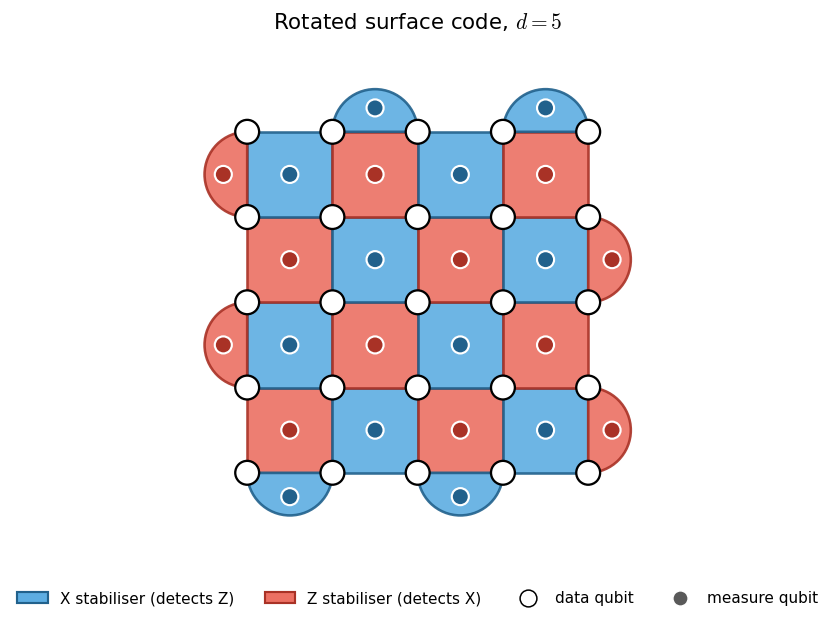

In [3]:
_SEMI = {"down": (180, 360), "up": (0, 180), "left": (90, 270), "right": (270, 90)}
_ANC_OFF = {"down": (0, -0.28), "up": (0, 0.28), "left": (-0.28, 0), "right": (0.28, 0)}
def _stab_center(s):                                      # ancilla (measure-qubit) position
    xs = [q[0] for q in s["qubits"]]; ys = [q[1] for q in s["qubits"]]
    cx, cy = sum(xs) / len(xs), sum(ys) / len(ys)
    if s["shape"] == "semi":
        dx, dy = _ANC_OFF[s["orient"]]; cx += dx; cy += dy
    return cx, cy

def _add_stab(ax, s, hi=False):
    fill = (C_Xhi if hi else C_X) if s["type"] == "X" else (C_Zhi if hi else C_Z)
    ed = C_Xed if s["type"] == "X" else C_Zed
    ec = "black" if hi else ed; lw = 2.8 if hi else 1.7; z = 3 if hi else 1
    if s["shape"] == "square":
        ax.add_patch(Polygon(s["qubits"], closed=True, facecolor=fill, edgecolor=ec,
                             lw=lw, alpha=1.0 if hi else 0.9, zorder=z))
    else:
        (ax_, ay), (bx, by) = s["qubits"]; mid = ((ax_ + bx) / 2, (ay + by) / 2)
        t1, t2 = _SEMI[s["orient"]]
        ax.add_patch(Wedge(mid, 0.5, t1, t2, facecolor=fill, edgecolor=ec,
                           lw=lw, alpha=1.0 if hi else 0.9, zorder=z))

def draw_code(ax, triggered=(), errors=(), logicals=(), title="", legend=True):
    for k, s in enumerate(STABS):
        _add_stab(ax, s, hi=(k in triggered))
    for s in STABS:                                       # ancilla / measure qubits at plaquette centres
        cx, cy = _stab_center(s)
        col = C_Xed if s["type"] == "X" else C_Zed
        ax.add_patch(Circle((cx, cy), 0.10, facecolor=col, edgecolor="white", lw=1.4, zorder=6))
    for (x, y) in DATA:                                   # data qubits
        ax.add_patch(Circle((x, y), 0.14, facecolor="white", edgecolor="black", lw=1.5, zorder=7))
    for kind, qubits, col, lab in logicals:               # logical operators as chains
        xs = [q[0] for q in qubits]; ys = [q[1] for q in qubits]
        ax.plot(xs, ys, "-", color=col, lw=5, alpha=0.55, zorder=4, solid_capstyle="round")
        ax.text(xs[-1] + 0.35 * (kind == "Z") + 0.0, ys[-1] + 0.35 * (kind == "X"),
                lab, color=col, fontsize=15, fontweight="bold", ha="center", va="center", zorder=7)
    for (x, y), pauli in errors:                          # error markers
        ax.scatter([x], [y], s=230, marker=("*" if pauli == "X" else "P"),
                   color=C_ERR, edgecolor="black", lw=1.1, zorder=8)
        ax.text(x, y - 0.42, f"${pauli}$ error", color="black", fontsize=11, ha="center", zorder=8)
    ax.set_xlim(-1.1, D + 0.1); ax.set_ylim(-1.1, D + 0.1); ax.set_aspect("equal"); ax.axis("off")
    if title: ax.set_title(title, fontsize=14)
    if legend:
        h = [Patch(facecolor=C_X, edgecolor=C_Xed, lw=1.4, label="X stabiliser (detects Z)"),
             Patch(facecolor=C_Z, edgecolor=C_Zed, lw=1.4, label="Z stabiliser (detects X)"),
             Line2D([0], [0], marker="o", color="w", markerfacecolor="white",
                    markeredgecolor="black", markersize=11, label="data qubit"),
             Line2D([0], [0], marker="o", color="w", markerfacecolor="0.35",
                    markeredgecolor="white", markersize=10, label="measure qubit")]
        ax.legend(handles=h, loc="upper center", bbox_to_anchor=(0.5, -0.02),
                  ncol=4, frameon=False, fontsize=10)

fig, ax = plt.subplots(figsize=(6.2, 6.6))
draw_code(ax, title="Rotated surface code, $d=5$")
savefig(fig, "rotated_surface_code_d5"); plt.show()

## 2. Logical operators

$\bar Z$ is a **horizontal** $Z$-chain spanning the two Z-boundaries (left/right); $\bar X$ is a **vertical**
$X$-chain spanning the two X-boundaries (top/bottom). They anticommute (cross on exactly one qubit), as a valid
logical pair must.

saved logical_operators_d5.svg/.png


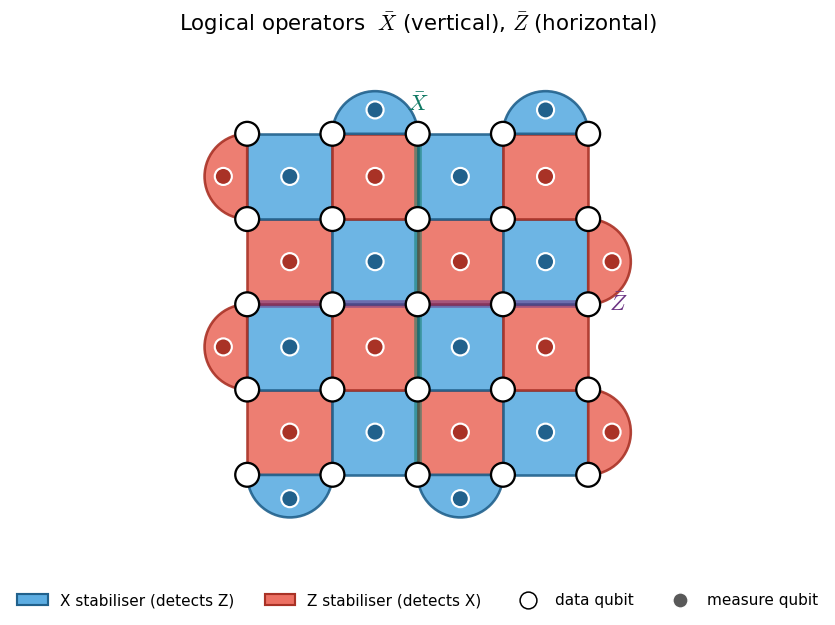

In [4]:
row = D // 2; coln = D // 2
LZ = ("Z", [(x, row) for x in range(D)], C_LZ, r"$\bar Z$")
LX = ("X", [(coln, y) for y in range(D)], C_LX, r"$\bar X$")
fig, ax = plt.subplots(figsize=(6.2, 6.6))
draw_code(ax, logicals=[LZ, LX], title=r"Logical operators  $\bar X$ (vertical), $\bar Z$ (horizontal)")
savefig(fig, "logical_operators_d5"); plt.show()

## 3. How errors trigger stabilisers

A single-qubit **$X$ error anticommutes with the adjacent $Z$-stabilisers** (red) — those detectors fire.
A **$Z$ error** does the same to the adjacent **$X$-stabilisers** (blue). Two separate figures for clarity.

saved error_triggers_stabilisers_d5.svg/.png


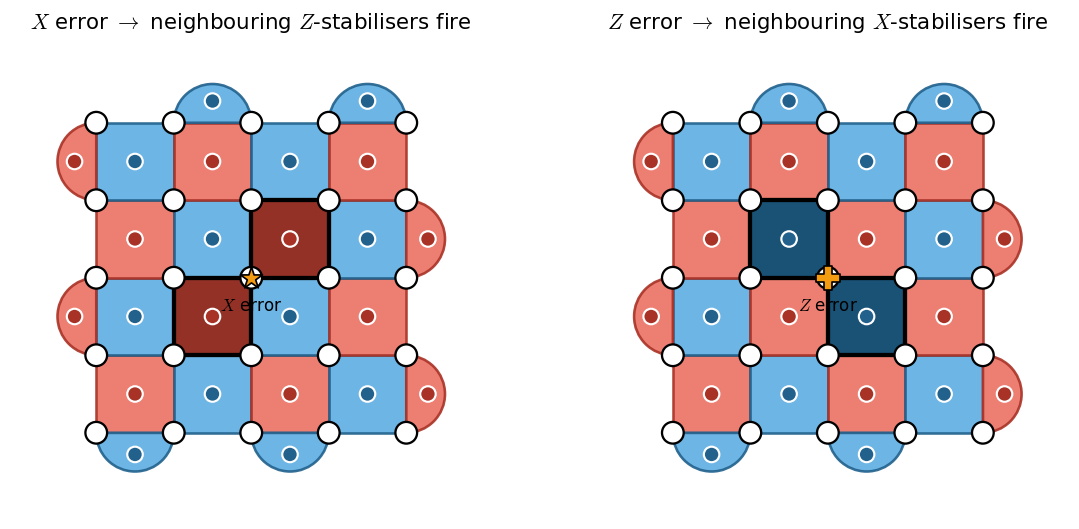

In [5]:
def triggered_by(q, pauli):
    want = "Z" if pauli == "X" else "X"      # X error lights Z-stabs; Z error lights X-stabs
    return [k for k, s in enumerate(STABS) if s["type"] == want and q in s["qubits"]]

q = (2, 2)
fig, ax = plt.subplots(1, 2, figsize=(12.4, 6.8))
draw_code(ax[0], triggered=triggered_by(q, "X"), errors=[(q, "X")],
          title=r"$X$ error $\rightarrow$ neighbouring $Z$-stabilisers fire", legend=False)
draw_code(ax[1], triggered=triggered_by(q, "Z"), errors=[(q, "Z")],
          title=r"$Z$ error $\rightarrow$ neighbouring $X$-stabilisers fire", legend=False)
savefig(fig, "error_triggers_stabilisers_d5"); plt.show()

### 3b. An error *chain*: only the endpoints fire

Along a chain the interior detectors are triggered twice and cancel (mod 2); only the two ends remain lit — this
is why the decoding problem is a *matching* of syndrome endpoints.

saved error_chain_endpoints_d5.svg/.png


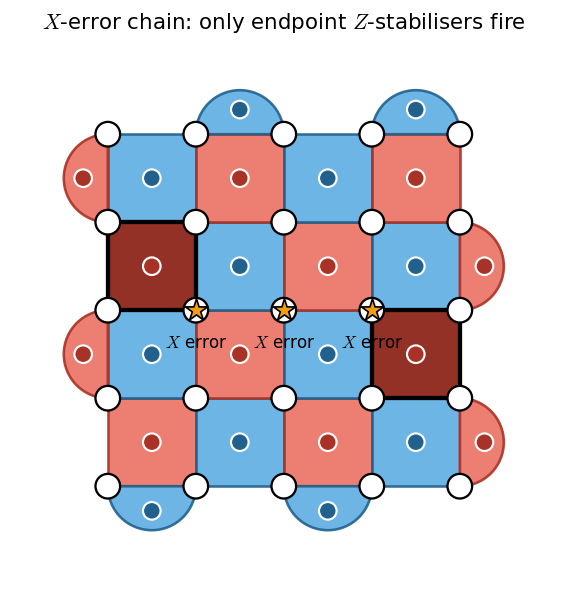

In [6]:
chain = [(1, 2), (2, 2), (3, 2)]                 # X-error chain
trig = set()
for qq in chain:
    trig ^= set(triggered_by(qq, "X"))          # XOR: interior cancels
fig, ax = plt.subplots(figsize=(6.4, 6.8))
draw_code(ax, triggered=trig, errors=[(qq, "X") for qq in chain],
          title=r"$X$-error chain: only endpoint $Z$-stabilisers fire", legend=False)
savefig(fig, "error_chain_endpoints_d5"); plt.show()

## 4. Syndrome-extraction circuit (Stim)

The `rotated_memory_z` experiment: reset → repeated rounds of stabiliser measurement → final data readout, with
detectors comparing consecutive rounds. Shown at **$d=3$, 2 rounds** so the gates are legible (the $d=5$ circuit
is identical in structure, just larger). We also render the 2D **detector slice** (which qubits each stabiliser
touches).

saved syndrome_extraction_circuit_d3.svg


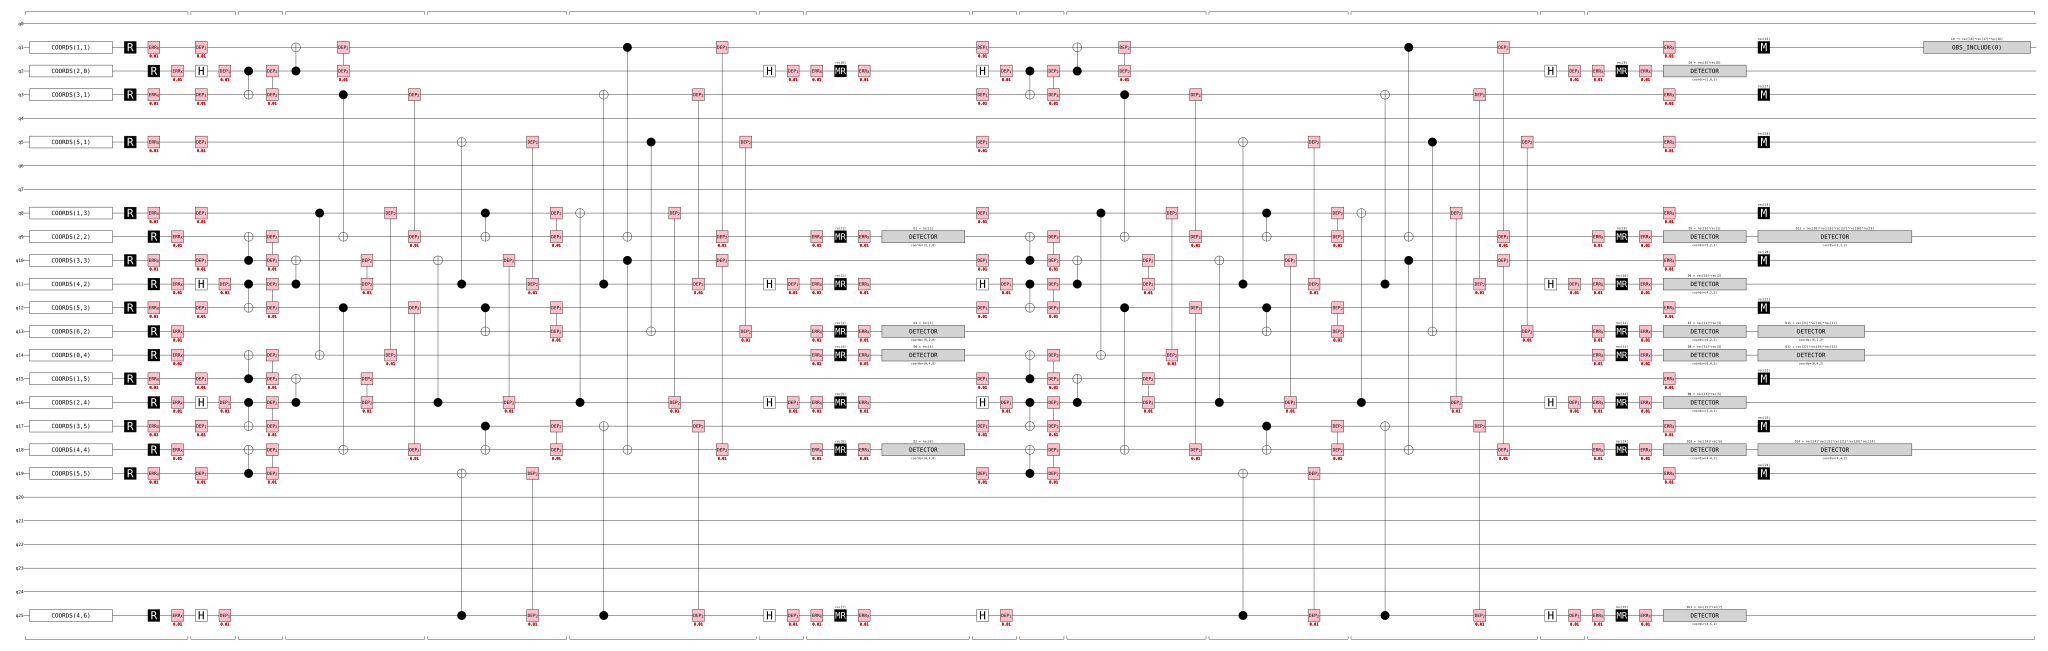

In [7]:
circ3 = stim.Circuit.generated("surface_code:rotated_memory_z", distance=3, rounds=2,
    after_clifford_depolarization=0.01, before_measure_flip_probability=0.01,
    after_reset_flip_probability=0.01, before_round_data_depolarization=0.01)
tl = circ3.diagram("timeline-svg")
open(os.path.join(FIG, "syndrome_extraction_circuit_d3.svg"), "w", encoding="utf-8").write(str(tl))
print("saved syndrome_extraction_circuit_d3.svg")
tl

saved detslice_with_ops_d3.svg, detslices_d5.svg


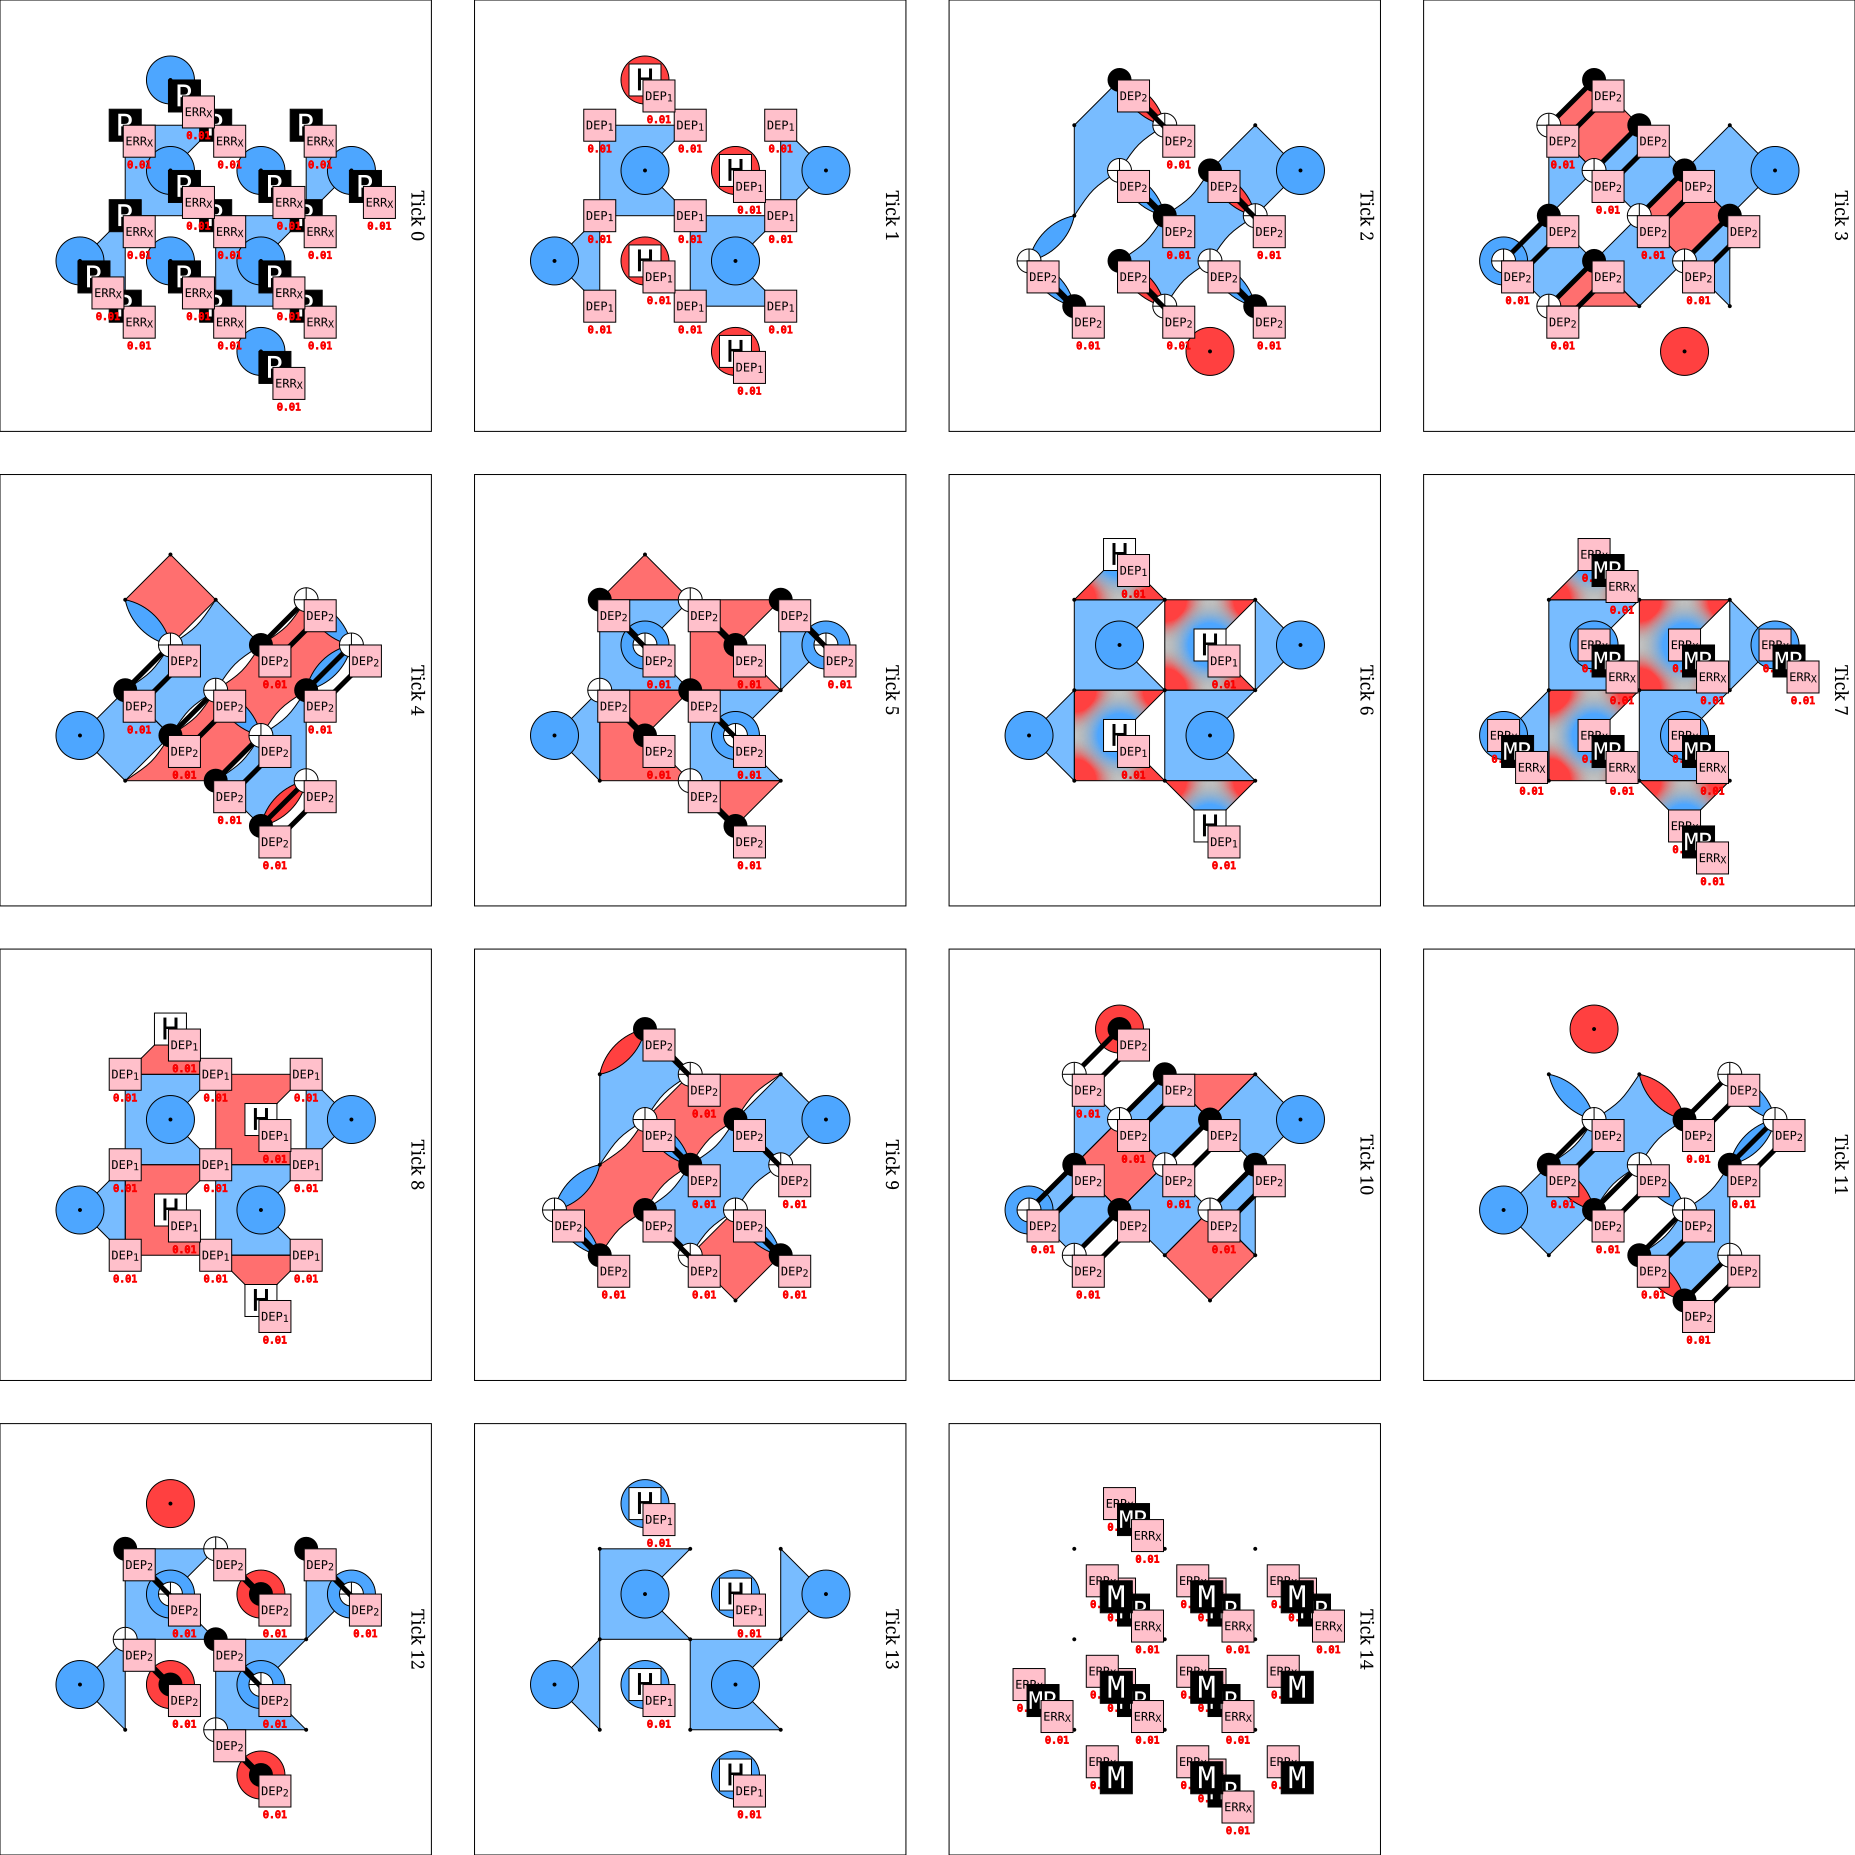

In [8]:
ds = circ3.diagram("detslice-with-ops-svg")
open(os.path.join(FIG, "detslice_with_ops_d3.svg"), "w", encoding="utf-8").write(str(ds))
# the d=5 stabiliser layout, straight from Stim (cross-check of our hand-drawn lattice)
circ5 = stim.Circuit.generated("surface_code:rotated_memory_z", distance=5, rounds=1)
ds5 = circ5.diagram("detslice-svg")
open(os.path.join(FIG, "detslices_d5.svg"), "w", encoding="utf-8").write(str(ds5))
print("saved detslice_with_ops_d3.svg, detslices_d5.svg")
ds

## 5. 3D decoding graph with fired detectors

Detectors live at $(x,y,t)$ — space across a round, and round index up the $t$-axis. Edges are the graphlike
error mechanisms of the DEM (each flips two detectors). We sample one shot and light up its **fired detectors**
(red); a decoder must pair these up along the edges. Shown at $d=3$ over several rounds for legibility.

d=3, 5 rounds: 40 detectors, 102 graph edges, 6 fired


saved decoding_graph_3d_fired.svg/.png


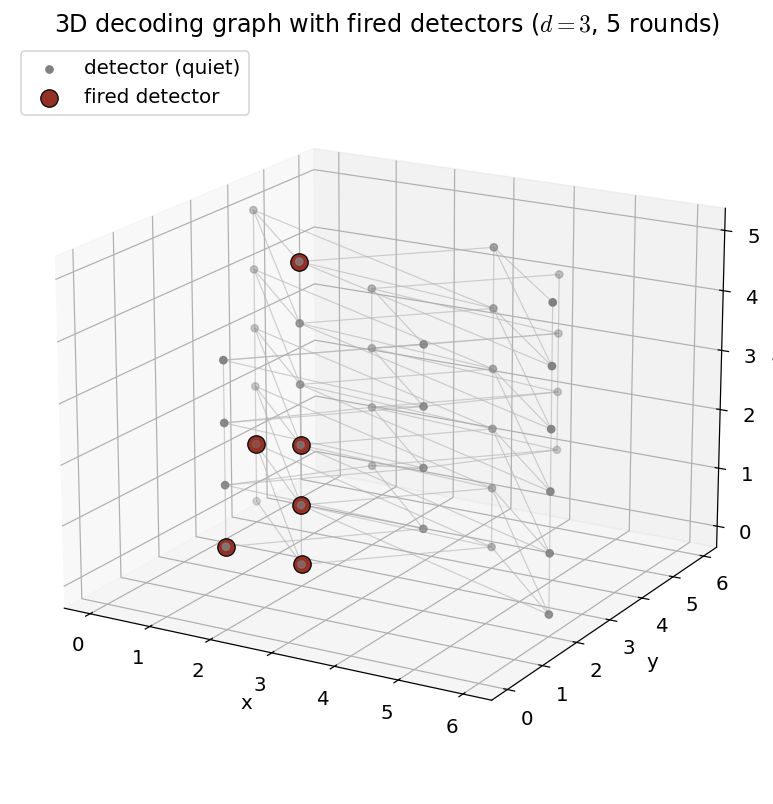

In [9]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
DG_D, DG_R = 3, 5
circ = stim.Circuit.generated("surface_code:rotated_memory_z", distance=DG_D, rounds=DG_R,
    after_clifford_depolarization=0.03, before_measure_flip_probability=0.03,
    after_reset_flip_probability=0.03, before_round_data_depolarization=0.03)
coords = circ.get_detector_coordinates()                       # {idx: [x, y, t]}
P = {i: (c[0], c[1], c[2] if len(c) > 2 else 0.0) for i, c in coords.items()}

# graphlike edges (2-detector components) from the decomposed DEM
edges = set()
for inst in circ.detector_error_model(decompose_errors=True).flattened():
    if inst.type != "error":
        continue
    comp = [[]]
    for t in inst.targets_copy():
        if t.is_separator():
            comp.append([])
        elif t.is_relative_detector_id():
            comp[-1].append(t.val)
    for grp in comp:
        if len(grp) == 2:
            edges.add(tuple(sorted(grp)))

# pick a shot with a handful of fired detectors
rng = np.random.default_rng(3)
sampler = circ.compile_detector_sampler(seed=7)
for _ in range(200):
    shot = sampler.sample(shots=1)[0]
    if 3 <= int(shot.sum()) <= 8:
        break
fired = np.flatnonzero(shot)
print(f"d={DG_D}, {DG_R} rounds: {len(P)} detectors, {len(edges)} graph edges, {len(fired)} fired")

fig = plt.figure(figsize=(8.5, 7.5)); ax = fig.add_subplot(projection="3d")
for a, b in edges:                                             # edges
    xa, ya, ta = P[a]; xb, yb, tb = P[b]
    ax.plot([xa, xb], [ya, yb], [ta, tb], color="0.7", lw=0.8, alpha=0.6, zorder=1)
xs = [P[i][0] for i in P]; ys = [P[i][1] for i in P]; ts = [P[i][2] for i in P]
ax.scatter(xs, ys, ts, s=22, color="0.5", depthshade=True, label="detector (quiet)")
ax.scatter([P[i][0] for i in fired], [P[i][1] for i in fired], [P[i][2] for i in fired],
           s=130, color=C_Zhi, edgecolor="black", lw=0.8, depthshade=False, label="fired detector")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("round  t")
ax.set_title(f"3D decoding graph with fired detectors ($d={DG_D}$, {DG_R} rounds)")
ax.legend(loc="upper left"); ax.view_init(elev=18, azim=-60)
fig.tight_layout(); savefig(fig, "decoding_graph_3d_fired"); plt.show()

In [10]:
# Bonus: Stim's own interactive 3D match graph (open the .html in a browser; rotate/zoom)
mg = circ.diagram("matchgraph-3d-html")
open(os.path.join(FIG, "matchgraph_3d.html"), "w", encoding="utf-8").write(str(mg))
print("saved matchgraph_3d.html  (open in a browser for an interactive rotatable version)")

saved matchgraph_3d.html  (open in a browser for an interactive rotatable version)


## Files written

Everything is in `plots/figures/` as SVG (vector, for LaTeX) + 300 dpi PNG:

- `rotated_surface_code_d5`, `logical_operators_d5`, `error_triggers_stabilisers_d5`, `error_chain_endpoints_d5`
- `syndrome_extraction_circuit_d3.svg`, `detslice_with_ops_d3.svg`, `detslices_d5.svg` (Stim)
- `decoding_graph_3d_fired`, `matchgraph_3d.html` (interactive)

Drop the SVGs straight into LaTeX with `\includegraphics`; they scale losslessly and keep editable text.